In [2]:
import numpy as np
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
import os

BASE_DIR = Path("/mnt/ceph/users/spandey/discodj_runs/halos_story_nsel_32768")
BASE_DIR_SAVE = Path("/mnt/ceph/users/spandey/discodj_runs/halos_story_nsel_4096")
N_FOLDERS = 2000
N_TOTAL = 32768
N_SELECT = 4096
SEED = 42

# Pre-generate indices once
np.random.seed(SEED)
INDICES = np.sort(np.random.choice(N_TOTAL, N_SELECT, replace=False))

def process_file(ji):
    in_path = BASE_DIR / str(ji) / f"halo_sentence_LH_{ji}.npy"
    out_path = BASE_DIR_SAVE / f"halo_sentence_nsel4096_LH_{ji}.npy"
    
    data = np.load(in_path)
    subsampled = data[INDICES]
    np.save(out_path, subsampled)
    return ji

if __name__ == "__main__":
    n_workers = min(32, os.cpu_count())
    
    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        for i, ji in enumerate(executor.map(process_file, range(N_FOLDERS))):
            if (i + 1) % 100 == 0:
                print(f"Processed {i + 1}/{N_FOLDERS}")
    
    print("Done")


    

    

Processed 100/2000
Processed 200/2000
Processed 300/2000
Processed 400/2000
Processed 500/2000
Processed 600/2000
Processed 700/2000
Processed 800/2000
Processed 900/2000
Processed 1000/2000
Processed 1100/2000
Processed 1200/2000
Processed 1300/2000
Processed 1400/2000
Processed 1500/2000
Processed 1600/2000
Processed 1700/2000
Processed 1800/2000
Processed 1900/2000
Processed 2000/2000
Done


In [323]:
"""
Halo catalog to sentence tokenization for machine learning.
Converts Rockstar halo catalogs into tokenized sequences for transformer models.
"""

import numpy as np
import os
import pickle as pk
import gc

import MAS_library as MASL
import sys
sys.path.insert(0, '/mnt/ceph/users/spandey/quijote_v2_gotham/GOTHAM/temp')
from ngp_funcs import NGP_xyz_prop
from colossus.cosmology import cosmology
from colossus.halo import mass_so

# Optional numba for acceleration
try:
    from numba import njit, prange
    HAS_NUMBA = True
except ImportError:
    HAS_NUMBA = False
    print("Warning: numba not available, using numpy fallback")


# =============================================================================
# Configuration
# =============================================================================

class Config:
    """All configuration parameters in one place."""
    # Grid parameters
    grid = 64
    pos_nvocab = 40
    grid_sbox = pos_nvocab
    grid_tot = grid * grid_sbox
    
    # Vocabulary
    nvocab = 131
    start_token = nvocab + 1
    space_token = nvocab + 2
    pad_token = nvocab + 3
    end_token = nvocab + 4
    
    # Data dimensions
    dim_pos = 3
    dim_prop = 5
    dim_tot = dim_pos + dim_prop
    
    # Sentence parameters
    Npoints_max_per_subvol = 36
    ind_token_to_sort = 3  # Sort by mass token
    add_space_token = False
    costoken_num = 5
    
    # Simulation parameters
    BoxSize = 1000.0
    redshift = 0.5
    snap_num = 3
    
    # Cosmology token ranges
    Om_min, Om_max = 0.1, 0.5
    Ob_min, Ob_max = 0.03, 0.07
    h0_min, h0_max = 0.5, 0.9
    ns_min, ns_max = 0.8, 1.2
    sigma8_min, sigma8_max = 0.6, 1.0
    
    # Paths
    sdir = '/mnt/ceph/users/spandey/discodj_runs/halos_story_nsel_32768'
    snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/latin_hypercube_HR'
    meta_dir = '/mnt/ceph/users/spandey/discodj_runs/rhog_LH_np_512_nsnap_3_nsel_32768/0'
    
    @classmethod
    def compute_bins(cls):
        """Compute digitization bins for each property."""
        bins = np.zeros((cls.dim_prop, cls.nvocab))
        
        # Mass bins
        bins[0] = np.linspace(12.7, 15.0, cls.nvocab)
        
        # Velocity bins (non-uniform: finer resolution near zero)
        # v_left = np.linspace(-1200, -100, cls.nvocab//3, endpoint=False)
        # v_mid = np.linspace(-100, 100, cls.nvocab - 2*(cls.nvocab//3), endpoint=False)
        # v_right = np.linspace(100, 1200, cls.nvocab//3, endpoint=True)
        # v_bins = np.concatenate((v_left, v_mid, v_right))
        v_bins = np.linspace(-1250, 1250, cls.nvocab)
        bins[1] = v_bins
        bins[2] = v_bins
        bins[3] = v_bins
        
        # Concentration bins
        bins[4] = np.linspace(1.0, 16.0, cls.nvocab)
        
        return bins
    
    @classmethod
    def get_max_sentence_length(cls):
        """Compute maximum sentence length."""
        if cls.add_space_token:
            return 1 + cls.Npoints_max_per_subvol * cls.dim_tot + 1 + (cls.Npoints_max_per_subvol - 1) + cls.costoken_num
        return 1 + cls.Npoints_max_per_subvol * cls.dim_tot + 1 + cls.costoken_num


# Pre-compute bins
BINS_DIGITIZE = Config.compute_bins()
MSTAR_CUT = BINS_DIGITIZE[0, 0]
PROP_MAX = np.array([BINS_DIGITIZE[i, -1] for i in range(Config.dim_prop)])
PROP_MIN = np.array([BINS_DIGITIZE[i, 0] for i in range(Config.dim_prop)])
MAX_SENTENCE_LENGTH = Config.get_max_sentence_length()


# =============================================================================
# Utility Functions
# =============================================================================

def mat_reshape(mat, grid1, grid2):
    """
    Reshape array from (grid1*grid2, grid1*grid2, grid1*grid2, ...) 
    to (grid1, grid1, grid1, grid2, grid2, grid2, ...).
    """
    if len(mat.shape) == 3:
        extra_dims = ()
    else:
        extra_dims = mat.shape[3:]
    
    n_extra = len(extra_dims)
    new_shape = (grid1, grid2, grid1, grid2, grid1, grid2) + extra_dims
    mat_rs = mat.reshape(new_shape)
    axes = (0, 2, 4, 1, 3, 5) + tuple(range(6, 6 + n_extra))
    return np.transpose(mat_rs, axes)


def tokenize_cosmo_param(value, vmin, vmax, nvocab):
    """Convert cosmological parameter to token."""
    token = np.round((value - vmin) / (vmax - vmin) * nvocab).astype(np.int16)
    return np.clip(token, 0, nvocab)


# =============================================================================
# Sentence Building Functions
# =============================================================================

def build_sentences_numpy(dfhalo_props_rs, Nhalos_rs, Om_token, sigma8_token, Ob_token, h0_token, ns_token, cfg):
    """
    Pure numpy implementation matching original logic exactly.
    Works without numba.
    """
    grid = cfg.grid
    grid_sbox = cfg.grid_sbox
    max_sent_len = MAX_SENTENCE_LENGTH
    
    sentences = np.full((grid, grid, grid, max_sent_len), cfg.pad_token, dtype=np.int16)
    total_halos_used = 0
    overflow_count = 0
    
    for jx in range(grid):
        for jy in range(grid):
            for jz in range(grid):
                props_subvol = dfhalo_props_rs[jx, jy, jz]
                Npoints_subvol = Nhalos_rs[jx, jy, jz]
                
                # Find cells with halos
                indsel = np.where(Npoints_subvol > 0)
                if len(indsel[0]) == 0:
                    sentences[jx, jy, jz, :7] = [cfg.start_token, Om_token, sigma8_token, Ob_token, h0_token, ns_token, cfg.end_token]
                    continue
                
                Npoints_sel = Npoints_subvol[indsel]
                props_sel = props_subvol[indsel]
                for ip in range(cfg.dim_prop):
                    props_sel[:, :, :, cfg.dim_pos + ip] = np.clip(
                        props_sel_orig[:, :, :, cfg.dim_pos + ip],
                        PROP_MIN[ip], PROP_MAX[ip]
                    )
                
                # Collect all halo tokens
                word_list = []
                for jc1 in range(len(Npoints_sel)):
                    n_pts = int(Npoints_sel[jc1])
                    for jc2 in range(n_pts):
                        pos_token = np.array([indsel[0][jc1], indsel[1][jc1], indsel[2][jc1]], dtype=np.int16)
                        prop_tokens = np.array([
                            np.digitize(props_sel[jc1, jc2, cfg.dim_pos + jp], BINS_DIGITIZE[jp])
                            for jp in range(cfg.dim_prop)
                        ], dtype=np.int16)
                        word_list.append(np.concatenate([pos_token, prop_tokens]))
                
                if len(word_list) == 0:
                    sentences[jx, jy, jz, :7] = [cfg.start_token, Om_token, sigma8_token, Ob_token, h0_token, ns_token, cfg.end_token]
                    continue
                
                word_array = np.array(word_list, dtype=np.int16)
                
                # Sort by mass token (descending)
                sort_idx = np.argsort(word_array[:, cfg.ind_token_to_sort])[::-1]
                word_array = word_array[sort_idx]
                
                # Truncate if needed
                if len(word_array) > cfg.Npoints_max_per_subvol:
                    overflow_count += 1
                    word_array = word_array[:cfg.Npoints_max_per_subvol]
                
                total_halos_used += len(word_array)
                
                # Build sentence
                if cfg.add_space_token:
                    space_col = np.full((len(word_array), 1), cfg.space_token, dtype=np.int16)
                    word_concat = np.hstack([word_array, space_col])
                    data_flat = word_concat.flatten()[:-1]
                else:
                    data_flat = word_array.flatten()
                
                sentence = np.concatenate([
                    [cfg.start_token, Om_token, sigma8_token, Ob_token, h0_token, ns_token, cfg.end_token],
                    data_flat,
                    [cfg.end_token]
                ]).astype(np.int16)
                
                sentences[jx, jy, jz, :len(sentence)] = sentence
    
    return sentences, overflow_count


# Numba-accelerated version (only defined if numba is available)
if HAS_NUMBA:
    @njit(parallel=True)
    def _build_sentences_numba(
        dfhalo_props_rs, Nhalos_rs, Om_token, sigma8_token,
        Ob_token, h0_token, ns_token,
        grid, grid_sbox, dim_tot, Npoints_max,
        start_token, end_token, pad_token,
        max_sent_len, bins_digitize, ind_sort
    ):
        """Numba-accelerated sentence building with parallel processing."""
        sentences = np.full((grid, grid, grid, max_sent_len), pad_token, dtype=np.int16)
        overflow_count = 0
        
        for jx in prange(grid):
            for jy in range(grid):
                for jz in range(grid):
                    props_here = dfhalo_props_rs[jx, jy, jz]
                    Npoints_here = Nhalos_rs[jx, jy, jz]
                    
                    # Count total points
                    total_points = 0
                    for i0 in range(grid_sbox):
                        for i1 in range(grid_sbox):
                            for i2 in range(grid_sbox):
                                total_points += int(Npoints_here[i0, i1, i2])
                    
                    if total_points == 0:
                        sentences[jx, jy, jz, 0] = start_token
                        sentences[jx, jy, jz, 1] = Om_token
                        sentences[jx, jy, jz, 2] = sigma8_token
                        sentences[jx, jy, jz, 3] = Ob_token
                        sentences[jx, jy, jz, 4] = h0_token
                        sentences[jx, jy, jz, 5] = ns_token
                        sentences[jx, jy, jz, 6] = end_token
                        continue
                    
                    # Collect all points
                    word_array = np.empty((total_points, dim_tot), dtype=np.int16)
                    idx = 0
                    for i0 in range(grid_sbox):
                        for i1 in range(grid_sbox):
                            for i2 in range(grid_sbox):
                                n_pts = int(Npoints_here[i0, i1, i2])
                                for jp in range(n_pts):
                                    word_array[idx, 0] = i0
                                    word_array[idx, 1] = i1
                                    word_array[idx, 2] = i2
                                    for ip in range(5):
                                        val = props_here[i0, i1, i2, jp, 3 + ip]
                                        tok = np.searchsorted(bins_digitize[ip], val)
                                        word_array[idx, 3 + ip] = np.int16(tok)
                                    idx += 1
                    
                    # Sort by ind_sort (descending)
                    sort_keys = word_array[:, ind_sort].copy()
                    sort_idx = np.argsort(sort_keys)[::-1]
                    word_array_sorted = word_array[sort_idx]
                    
                    # Truncate
                    n_use = min(total_points, Npoints_max)
                    if total_points > Npoints_max:
                        overflow_count += 1
                    
                    # Build sentence
                    sentences[jx, jy, jz, 0] = start_token
                    sentences[jx, jy, jz, 1] = Om_token
                    sentences[jx, jy, jz, 2] = sigma8_token
                    sentences[jx, jy, jz, 3] = Ob_token
                    sentences[jx, jy, jz, 4] = h0_token
                    sentences[jx, jy, jz, 5] = ns_token

                    
                    pos = 6
                    for i in range(n_use):
                        for j in range(dim_tot):
                            sentences[jx, jy, jz, pos] = word_array_sorted[i, j]
                            pos += 1
                    
                    sentences[jx, jy, jz, pos] = end_token
        
        return sentences, overflow_count
    
    def build_sentences_numba(dfhalo_props_rs, Nhalos_rs, Om_token, sigma8_token, Ob_token, h0_token, ns_token, cfg):
        """Wrapper for numba function with Config object."""
        return _build_sentences_numba(
            dfhalo_props_rs, Nhalos_rs, Om_token, sigma8_token, Ob_token, h0_token, ns_token,
            cfg.grid, cfg.grid_sbox, cfg.dim_tot, cfg.Npoints_max_per_subvol,
            cfg.start_token, cfg.end_token, cfg.pad_token,
            MAX_SENTENCE_LENGTH, BINS_DIGITIZE, cfg.ind_token_to_sort
        )


def build_sentences(dfhalo_props_rs, Nhalos_rs, Om_token, sigma8_token, Ob_token, h0_token, ns_token, cfg, use_numba=True):
    """
    Build sentences using the fastest available method.
    
    Args:
        use_numba: If True and numba available, use parallel numba version
    """
    if use_numba and HAS_NUMBA:
        return build_sentences_numba(dfhalo_props_rs, Nhalos_rs, Om_token, sigma8_token, Ob_token, h0_token, ns_token, cfg)
    return build_sentences_numpy(dfhalo_props_rs, Nhalos_rs, Om_token, sigma8_token, Ob_token, h0_token, ns_token, cfg)


# =============================================================================
# I/O and Processing Functions
# =============================================================================

def save_sentence_params():
    """Save sentence configuration parameters."""
    saved = {
        'max_sentence_length': MAX_SENTENCE_LENGTH,
        'grid': Config.grid,
        'grid_sbox': Config.grid_sbox,
        'Npoints_max_per_subvol': Config.Npoints_max_per_subvol,
        'BoxSize': Config.BoxSize,
        'nvocab': Config.nvocab,
        'pos_nvocab': Config.pos_nvocab,
        'start_token': Config.start_token,
        'pad_token': Config.pad_token,
        'end_token': Config.end_token,
        'space_token': Config.space_token,
        'bins_digitize': BINS_DIGITIZE,
        'dim_pos': Config.dim_pos,
        'dim_prop': Config.dim_prop
    }
    os.makedirs(Config.sdir, exist_ok=True)
    pk.dump(saved, open(f"{Config.sdir}/sentence_params.pkl", 'wb'))
    print("Sentence parameters saved.")


def load_halo_catalog(isim, cosmo_params):
    """Load and filter Rockstar halo catalog."""
    Om, Ob, h0, ns, sigma8 = cosmo_params
    
    # Set up colossus cosmology
    params = {
        'flat': True, 'H0': h0 * 100, 'Om0': Om,
        'Ob0': Ob, 'sigma8': sigma8, 'ns': ns
    }
    cosmology.setCosmology('myCosmo', persistence='', **params)
    
    # Load Rockstar catalog
    snapdir = f"{Config.snap_dir_base}/{isim}"
    catalog_file = f"{snapdir}/out_{Config.snap_num}_pid.list"
    
    with open(catalog_file, 'r') as f:
        header = f.readline().split()
    
    rockstar = np.loadtxt(catalog_file)
    
    # Extract properties
    pos = rockstar[:, header.index('X'):header.index('Z')+1]
    mass = rockstar[:, header.index('M200c')]
    lgMass = np.log10(mass).astype(np.float32)
    lgMass = np.clip(lgMass, 0, PROP_MAX[0])
    
    vel = rockstar[:, header.index('VX'):header.index('VZ')+1]
    
    # Concentration
    Rhalo = (1 + Config.redshift) * mass_so.M_to_R(mass, Config.redshift, '200c')
    Rs = rockstar[:, header.index('Rs')]
    conc = Rhalo / Rs
    
    pid = rockstar[:, -1]
    
    # Stack properties: [lgM, vx, vy, vz, conc]
    props = np.column_stack((lgMass, vel, conc))
    
    # Filter: central halos above mass cut
    mask = (pid == -1) & (lgMass > MSTAR_CUT)
    
    return pos[mask].astype(np.float32), props[mask].astype(np.float32)


def process_LH_sim(isim, use_numba=True, randsel=True):
    """Process a single Latin Hypercube simulation."""
    # Setup output directory
    sdir_isim = f"{Config.sdir}/{isim}"
    os.makedirs(sdir_isim, exist_ok=True)
    
    # Load metadata
    meta_file = f"{Config.meta_dir}/meta_dmo_fields_subvols_grid_8_LH_{isim}.pkl"
    with open(meta_file, 'rb') as f:
        metaf = pk.load(f)
    if randsel:
        rand_sel = metaf['rand_sel']
        savefname = f"{sdir_isim}/halo_sentence_LH_{isim}.npy"

    else:
        rand_sel = np.arange(Config.grid**3)
        savefname = f"{sdir_isim}/halo_sentence_LH_{isim}_full.npy"

    cosmo = metaf['cosmo']
    
    Om = cosmo['Omega_c'] + cosmo['Omega_b']
    Ob = cosmo['Omega_b']
    h0 = cosmo['h']
    ns = cosmo['n_s']
    sigma8 = cosmo['sigma8']
    
    # Tokenize cosmological parameters
    Om_token = tokenize_cosmo_param(Om, Config.Om_min, Config.Om_max, Config.nvocab)
    sigma8_token = tokenize_cosmo_param(sigma8, Config.sigma8_min, Config.sigma8_max, Config.nvocab)
    Ob_token = tokenize_cosmo_param(Ob, Config.Ob_min, Config.Ob_max, Config.nvocab)
    h0_token = tokenize_cosmo_param(h0, Config.h0_min, Config.h0_max, Config.nvocab)
    ns_token = tokenize_cosmo_param(ns, Config.ns_min, Config.ns_max, Config.nvocab)
    
    # Load halo catalog
    pos, props = load_halo_catalog(isim, (Om, Ob, h0, ns, sigma8))
    
    # NGP assignment to grid
    grid_tot = Config.grid_tot
    Nhalos = np.zeros((grid_tot, grid_tot, grid_tot), dtype=np.float32)
    MASL.NGP(pos, Nhalos, Config.BoxSize)
    
    nMax = int(np.amax(Nhalos))
    dfhalo_props = np.zeros(
        (grid_tot, grid_tot, grid_tot, nMax, Config.dim_pos + Config.dim_prop),
        dtype=np.float32
    )
    NGP_xyz_prop(pos, props, dfhalo_props, Config.BoxSize)
    
    # Reshape to subvolume structure
    Nhalos_rs = mat_reshape(Nhalos, Config.grid, Config.grid_sbox)
    dfhalo_props_rs = mat_reshape(dfhalo_props, Config.grid, Config.grid_sbox)
    
    # Free memory
    del pos, props, Nhalos, dfhalo_props
    gc.collect()
    
    # Build sentences
    sentences, overflow = build_sentences(
        dfhalo_props_rs, Nhalos_rs, Om_token, sigma8_token, Ob_token, h0_token, ns_token, Config, use_numba=use_numba
    )
    
    if overflow > 0:
        print(f"Sim {isim}: {overflow} subvolumes exceeded max points ({Config.Npoints_max_per_subvol})")
    
    # Flatten and apply random selection
    story_full = sentences.reshape((Config.grid**3, MAX_SENTENCE_LENGTH))
    np.save(savefname, story_full[rand_sel].astype(np.int16))
    
    # Cleanup
    del dfhalo_props_rs, Nhalos_rs, sentences, story_full
    gc.collect()


# =============================================================================
# Entry Point
# =============================================================================

# if __name__ == "__main__":
#     save_sentence_params()
    
    # Example: process single simulation
    # process_LH_sim(0)
    
    # For batch processing with MPI:
    # from mpi4py import MPI
    # comm = MPI.COMM_WORLD
    # for isim in range(1000):
    #     if isim % comm.size == comm.rank:
    #         process_LH_sim(isim)

In [324]:
# for i in numbers:
save_sentence_params()
process_LH_sim(0, randsel=False)




Sentence parameters saved.


/tmp/ipykernel_884343/3739356478.py:380: RuntimeWarning: divide by zero encountered in log10
  lgMass = np.log10(mass).astype(np.float32)


In [325]:
story_full = np.load('/mnt/ceph/users/spandey/discodj_runs/halos_story_nsel_32768/0/halo_sentence_LH_0_full.npy')
story_full.shape



(262144, 295)

In [326]:
sentence_params = pk.load(open('/mnt/ceph/users/spandey/discodj_runs/halos_story_nsel_32768/sentence_params.pkl', 'rb'))
print(sentence_params.keys())
BoxSize = sentence_params['BoxSize']
grid = sentence_params['grid']
pos_nvocab = sentence_params['pos_nvocab']
bins_digitize = sentence_params['bins_digitize']
dim_pos = sentence_params['dim_pos']
dim_prop = sentence_params['dim_prop']
start_token = sentence_params['start_token']
pad_token = sentence_params['pad_token']
end_token = sentence_params['end_token']



dict_keys(['max_sentence_length', 'grid', 'grid_sbox', 'Npoints_max_per_subvol', 'BoxSize', 'nvocab', 'pos_nvocab', 'start_token', 'pad_token', 'end_token', 'space_token', 'bins_digitize', 'dim_pos', 'dim_prop'])


In [327]:
end_token


135

In [328]:
xarray
# BoxSize/grid

array([ 0.1953125,  0.5859375,  0.9765625,  1.3671875,  1.7578125,
        2.1484375,  2.5390625,  2.9296875,  3.3203125,  3.7109375,
        4.1015625,  4.4921875,  4.8828125,  5.2734375,  5.6640625,
        6.0546875,  6.4453125,  6.8359375,  7.2265625,  7.6171875,
        8.0078125,  8.3984375,  8.7890625,  9.1796875,  9.5703125,
        9.9609375, 10.3515625, 10.7421875, 11.1328125, 11.5234375,
       11.9140625, 12.3046875, 12.6953125, 13.0859375, 13.4765625,
       13.8671875, 14.2578125, 14.6484375, 15.0390625, 15.4296875])

In [329]:
xall = (np.linspace(0, BoxSize/grid, pos_nvocab + 1))
xarray = 0.5 * (xall[1:] + xall[:-1])
yarray = np.copy(xarray)
zarray = np.copy(xarray)
# bins_digitize = np.linspace(-1e-3, 1, nvocab)


# dim_pos = 3
# dim_prop = len(prop_min)   
dim_tot = dim_pos + dim_prop


# BoxSize = 1000.
# grid = 8
xmin = BoxSize/grid/2

MAS     = 'NGP'  #mass-assigment scheme
# grid_Pk = 16
# threads = 10

def get_prop_pos(X_val, grid=1):
    pos_infer_all = []
    prop_infer_all = []
    for jx in range(grid):
        for jy in range(grid):
            for jz in range(grid):
                sentence_here = X_val[jx, jy, jz]
                if add_space_token:
                    ntokens_per_halo = dim_tot + 1
                else:
                    ntokens_per_halo = dim_tot
                ind_start_token = 5
                if end_token in sentence_here:
                    ind_end_token = np.where(sentence_here == end_token)[0]
                    try:
                        Nhalos_here = ((ind_end_token - ind_start_token - 1) / ntokens_per_halo)[0]
                    except:
                        print(ind_end_token, ind_start_token, ntokens_per_halo)
                    if (int(Nhalos_here) - Nhalos_here) != 0:
                        Nhalos_here = ((ind_end_token - ind_start_token ) / ntokens_per_halo)[0]
                        # print(Nhalos_here, Nhalos_here2, 'Nhalos_here is not an integer')
                        # pass
                    if (int(Nhalos_here) - Nhalos_here) != 0:
                        print(Nhalos_here, 'Nhalos_here is not an integer')
                    else:
                        if Nhalos_here > 0:
                            for jh in range(int(Nhalos_here)):
                                try:
                                    prop_all = np.zeros(dim_prop)        
                                    for jp in range(dim_prop):
                                        delta_bin = (bins_digitize[jp][-1] - bins_digitize[jp][0]) / (len(bins_digitize[jp]) - 1)
                                        noise_val = np.random.uniform(-delta_bin/2, delta_bin/2)
                                        # noise_val = 0.0
                                        bin_val_jp = sentence_here[ind_start_token + jh*ntokens_per_halo+ dim_pos + 1 + jp]
                                        # try:
                                            # if jh == 0:
                                        # prop_all[jp] = prop_min[jp] + (prop_max[jp] - prop_min[jp]) * (bins_digitize[bin_val_jp] + noise_val)
                                        if bin_val_jp < len(bins_digitize[jp]):
                                            prop_all[jp] = bins_digitize[jp][bin_val_jp] + noise_val
                                        else:
                                            prop_all[jp] = bins_digitize[jp][-1] + noise_val
                                            # else:
                                            #     prop_all[jp] = 0.0
                                        # except:
                                            # pass

                                    # print( prop_all)
                                    coord_x = (xarray[sentence_here[ind_start_token + jh*ntokens_per_halo+ 1]] + (BoxSize/grid)*jx) % BoxSize
                                    coord_y = (yarray[sentence_here[ind_start_token + jh*ntokens_per_halo  + 2]] + (BoxSize/grid)*jy) % BoxSize
                                    coord_z = (zarray[sentence_here[ind_start_token + jh*ntokens_per_halo  + 3]] + (BoxSize/grid)*jz) % BoxSize
                                    pos_infer_all.append([coord_x, coord_y, coord_z])
                                            # print(sentence_here)
                                    prop_infer_all.append(prop_all)

                                except Exception as e:
                                    print(jx, jy, jz, jh, Nhalos_here, e)
                                    pass
                                    # print(sentence_here[ind_start_token], ntokens_per_halo)
                else:           
                    print('End token not found')
                    pass

    pos_infer_all = np.array(pos_infer_all)
    prop_infer_all = np.array(prop_infer_all)


    return pos_infer_all, prop_infer_all


    

In [330]:
grid = 64
pos_infer_all, prop_infer_all = get_prop_pos(story_full.reshape((grid, grid, grid, story_full.shape[-1])), grid=grid)


In [331]:
isim = 0
meta_file = f"{Config.meta_dir}/meta_dmo_fields_subvols_grid_8_LH_{isim}.pkl"
with open(meta_file, 'rb') as f:
    metaf = pk.load(f)
cosmo = metaf['cosmo']

Om = cosmo['Omega_c'] + cosmo['Omega_b']
Ob = cosmo['Omega_b']
h0 = cosmo['h']
ns = cosmo['n_s']
sigma8 = cosmo['sigma8']
cosmo_array = (Om, Ob, h0, ns, sigma8)

pos_true, prop_true = load_halo_catalog(isim,cosmo_array)


/tmp/ipykernel_884343/3739356478.py:380: RuntimeWarning: divide by zero encountered in log10
  lgMass = np.log10(mass).astype(np.float32)


In [332]:
pos_true.shape, prop_true.shape



((117133, 3), (117133, 5))

In [333]:
import matplotlib.pyplot as plt


In [334]:
pos_infer_all[:,0]


array([ 13.0859375,  11.9140625,  11.5234375, ..., 993.5546875,
       999.0234375, 996.6796875], shape=(117133,))

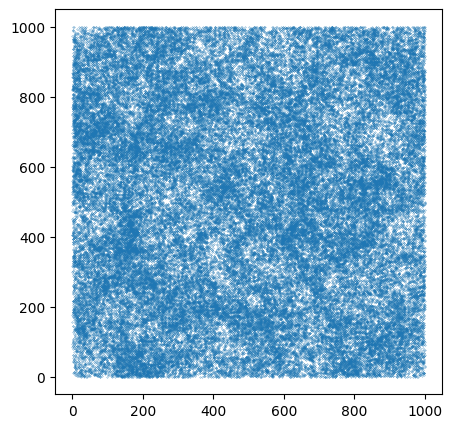

In [335]:
plt.figure(figsize=(5,5))
plt.scatter(pos_infer_all[:,0], pos_infer_all[:,1], s=0.05)




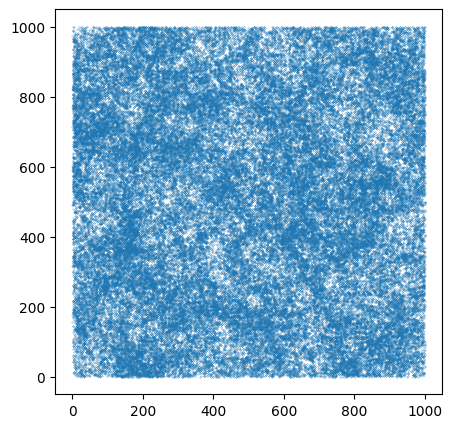

In [336]:
plt.figure(figsize=(5,5))
plt.scatter(pos_true[:,0], pos_true[:,1], s=0.05)




In [41]:
import numpy as np
# cat_gt = '/mnt/ceph/users/spandey/discodj_runs/quijote_generated_halo_cats/generated_halo_catalog_0.npy'
cat_gt = '/mnt/ceph/users/spandey/discodj_runs/quijote_generated_halo_cats/generated_halo_catalog_0.npy'
cat_gen = np.load(cat_gt)
print(cat_gen.shape)


(132147, 8)


In [42]:
# cat_gen[0,:]
import math
math.floor(22.4)


22

In [43]:
cosmo_params = np.loadtxt('/mnt/ceph/users/spandey/quijote_v2_gotham/GOTHAM/checkpoints/quijote_params.txt')
Om0_all = cosmo_params[:,0]
argsort_Om = np.argsort(Om0_all)
np.where(argsort_Om == 0)


(array([377]),)

In [44]:
from colossus.cosmology import cosmology
from colossus.halo import mass_so

snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/latin_hypercube_HR'
isim = 0
snap_num = 3
redshift = 0.5

cosmo_params = np.loadtxt('/mnt/ceph/users/spandey/quijote_v2_gotham/GOTHAM/checkpoints/quijote_params.txt')[isim]

Om, Ob, h0, ns, sigma8 = cosmo_params
params = {
    'flat': True, 'H0': h0 * 100, 'Om0': Om,
    'Ob0': Ob, 'sigma8': sigma8, 'ns': ns
}
cosmology.setCosmology('myCosmo', persistence='', **params)

# Load Rockstar catalog
snapdir = f"{snap_dir_base}/{isim}"
catalog_file = f"{snapdir}/out_{snap_num}_pid.list"

with open(catalog_file, 'r') as f:
    header = f.readline().split()

rockstar = np.loadtxt(catalog_file)

# Extract properties
pos = rockstar[:, header.index('X'):header.index('Z')+1]
mass = rockstar[:, header.index('M200c')]
lgMass = np.log10(mass).astype(np.float32)
# lgMass = np.clip(lgMass, 0, PROP_MAX[0])

vel = rockstar[:, header.index('VX'):header.index('VZ')+1]

# Concentration
Rhalo = (1 + redshift) * mass_so.M_to_R(mass, redshift, '200c')
Rs = rockstar[:, header.index('Rs')]
conc = Rhalo / Rs

pid = rockstar[:, -1]

# Stack properties: [lgM, vx, vy, vz, conc]
props = np.column_stack((lgMass, vel, conc))

# Filter: central halos above mass cut
MSTAR_CUT = 12.7
mask = (pid == -1) & (lgMass > MSTAR_CUT)

pos_orig, prop_orig = pos[mask].astype(np.float32), props[mask].astype(np.float32)


/tmp/ipykernel_449825/3716002020.py:30: RuntimeWarning: divide by zero encountered in log10
  lgMass = np.log10(mass).astype(np.float32)


In [45]:
pos_infer_all = cat_gen[:, :3]
prop_infer_all = cat_gen[:, 3:]
pos_true = pos_orig
prop_true = prop_orig


In [46]:
pos_infer_all.shape, pos_true.shape




((132147, 3), (117133, 3))

In [47]:
import numpy as np
import MAS_library as MASL

# density field parameters
grid    = 1024    #the 3D field will have grid x grid x grid voxels
BoxSize = 1000.0 #Mpc/h ; size of box
MAS     = 'TSC'  #mass-assigment scheme
verbose = True   #print information on progress

delta_dj = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos_infer_all.astype(np.float32), delta_dj, BoxSize, MAS, verbose=verbose)

import numpy as np
import readgadget


delta_q = np.zeros((grid,grid,grid), dtype=np.float32)

# construct 3D density field
MASL.MA(pos_true.astype(np.float32), delta_q, BoxSize, MAS, verbose=verbose)


delta_dj /= np.mean(delta_dj, dtype=np.float32);  delta_dj -= 1.0

delta_q /= np.mean(delta_q, dtype=np.float32);  delta_q -= 1.0


import Pk_library as PKL

Pk = PKL.XPk([delta_dj,delta_q], BoxSize, 0, MAS=['CIC','CIC'], threads=1)









Using TSC mass assignment scheme
Time taken = 0.863 seconds


Using TSC mass assignment scheme
Time taken = 0.824 seconds


Computing power spectra of the fields...
Time FFTS = 32.95
Time loop = 21.08
Time taken = 54.04 seconds


(0.8, 1.05)

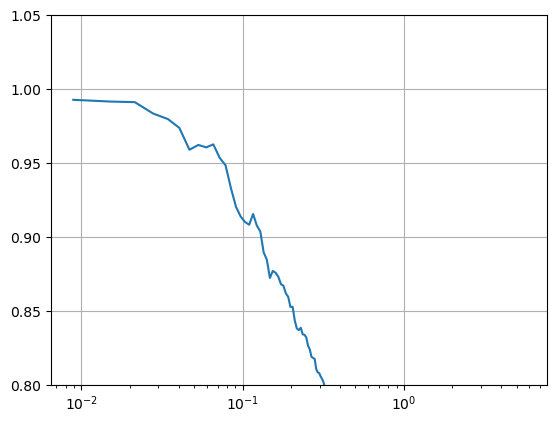

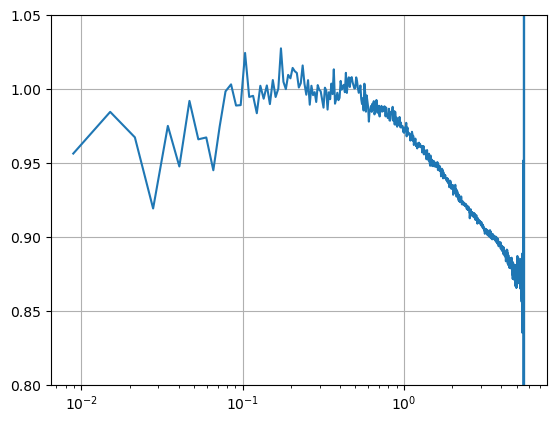

In [48]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(Pk.k3D, Pk.XPk[:,0,0]/np.sqrt(Pk.Pk[:,0,0] * Pk.Pk[:,0,1]), label='Disco-DJ')
plt.xscale('log')
plt.grid()
plt.ylim(0.8, 1.05)

plt.figure()
plt.plot(Pk.k3D, Pk.Pk[:,0,0] / Pk.Pk[:,0,1], label='Disco-DJ')
plt.xscale('log')
plt.grid()
plt.ylim(0.8, 1.05)


In [15]:
prop_true


array([[  12.818088 ,  -54.18     , -150.5      ,   75.14     ,
           1.1652682],
       [  13.434137 ,  143.01     , -178.43     , -150.13     ,
           7.3441453],
       [  13.010809 ,  275.27     ,  -88.93     ,   91.87     ,
           7.3713613],
       ...,
       [  12.717413 ,  383.46     ,   40.93     ,  120.86     ,
           4.255178 ],
       [  12.732265 ,  172.22     ,   15.1      ,   54.93     ,
           2.302373 ],
       [  13.230756 ,  192.67     , -233.25     ,  448.68     ,
           5.816069 ]], dtype=float32)

Text(0.5, 0, 'log(Mass)')

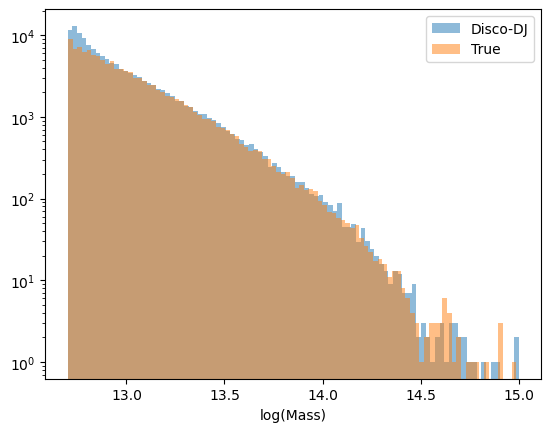

In [38]:
plt.figure()
_ = plt.hist(np.log10(prop_infer_all[:,0]), bins=97, alpha=0.5, label='Disco-DJ')
_ = plt.hist((prop_true[:,0]), bins=97, alpha=0.5, label='True')
plt.legend()
plt.yscale('log')
plt.xlabel('log(Mass)')




Text(0.5, 0, 'log(Mass)')

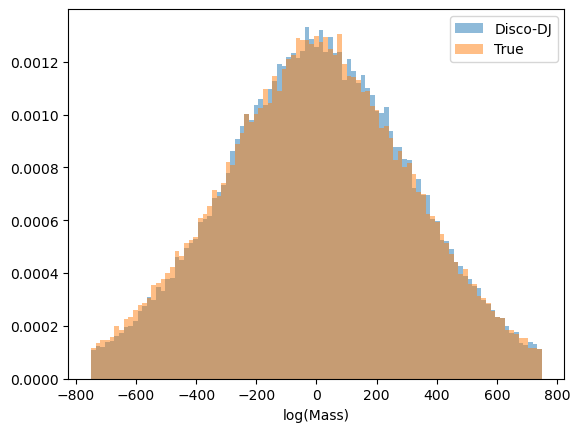

In [39]:
plt.figure()
_ = plt.hist(prop_infer_all[:,1], bins=97, range=(-750,750), alpha=0.5, label='Disco-DJ', density=True)
_ = plt.hist(prop_true[:,1], bins=97, range=(-750,750), alpha=0.5, label='True', density=True)
plt.legend()
# plt.yscale('log')
plt.xlabel('log(Mass)')




Text(0.5, 0, 'log(Mass)')

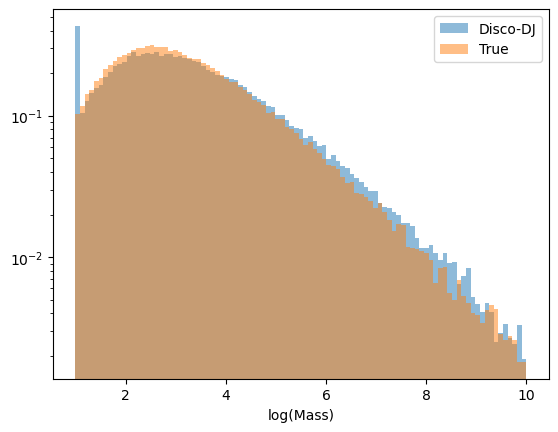

In [40]:
plt.figure()
_ = plt.hist(prop_infer_all[:,4], bins=97, range=(1, 10), alpha=0.5, label='Disco-DJ', density=True)
_ = plt.hist(prop_true[:,4], bins=97, range=(1, 10), alpha=0.5, label='True', density=True)
plt.legend()
plt.yscale('log')

plt.xlabel('log(Mass)')


